[![](imagens/colab-badge.png){width="16%"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap03/cap03_aluno.ipynb)
[![](imagens/github-badge.png){width="20%"}](https://github.com/fzampirolli/pdi-vc)

# Operações Espaciais: Intensidade, Histograma e Filtragem

Este capítulo aprofunda o processamento de imagens no domínio espacial, partindo da manipulação direta de pixels e histogramas para o realce de contraste, até a aplicação de filtros locais por convolução para suavização, redução de ruído e detecção de bordas. O objetivo é desenvolver a intuição matemática e computacional que sustenta grande parte dos algoritmos modernos de Visão Computacional.

## Objetivos

Ao final deste capítulo, você será capaz de:

* **Manipular intensidade e pixels:** Executar operações aritméticas e lógicas (como subtração de fundo e máscaras bit a bit) e aplicar técnicas de realce por processamento de histograma (equalização e especificação);
* **Compreender fundamentos espaciais:** Entender os conceitos de vizinhança espacial, os mecanismos de convolução/correlação e o papel dos *kernels* (máscaras);
* **Aplicar filtragem espacial de suavização:** Utilizar filtros lineares de média e Gaussiano para redução de ruído e atenuação de detalhes;
* **Aplicar filtragem espacial de realce:** Dominar o uso de filtros de nitidez e bordas, como o Laplaciano, Sobel e a técnica de *Unsharp Masking*;
* **Utilizar filtros de ordem:** Aplicar o filtro de mediana para a remoção eficaz de ruídos específicos, como o ruído do tipo sal e pimenta;
* **Resolver problemas práticos:** Combinar essas técnicas de processamento e filtragem no pré-processamento de imagens para aplicações reais.

## Operações em Nível de Intensidade

O nível mais elementar de processamento de imagens atua diretamente sobre os valores dos pixels, sem considerar vizinhança. Essas operações — chamadas de **transformações de ponto** (*point operations*) — são as mais rápidas computacionalmente e formam a base para técnicas mais complexas.

Formalmente, uma transformação de ponto pode ser descrita como:

$$
g(x,y) = T[f(x,y)]
$$ {#eq-03-ponto}

onde $f(x,y)$ é a imagem de entrada, $g(x,y)$ é a saída e $T$ é uma função aplicada a cada pixel individualmente.

In [ ]:
#| quarto-raw: true

import os, importlib, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Baixar morph.py se necessário
BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph"
for f in ["morph.py"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"{BASE_URL}/{f}", f)

import morph
importlib.reload(morph)
from morph import mm

print("✅ Ambiente pronto")

✅ Ambiente pronto


In [ ]:
#| quarto-raw: true

# Carregar imagem de exemplo (Lena)
url_lena = "https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png"
img_color = mm.read(url_lena)
img_gray = mm.gray(img_color)
print(f"Imagem original: {img_color.shape}")
print(f"Tipo da imagem: {type(img_gray)}")

Imagem original: (512, 512, 3)
Tipo da imagem: <class 'numpy.ndarray'>


### Operações Aritméticas

Operações aritméticas entre imagens são amplamente usadas em PDI para combinar, comparar ou realçar informações. A **subtração de imagens** é especialmente poderosa para detectar diferenças entre dois quadros — por exemplo, na remoção de fundo estático em câmeras de vigilância:

$$
g(x,y) = f_1(x,y) - f_2(x,y)
$$ {#eq-03-subtracao}

A **adição saturada** limita o resultado ao intervalo $[0, 255]$: valores acima de 255 são fixados em 255, evitando o *overflow* silencioso do tipo `uint8` (ex.: $200 + 100 = 44$ em vez de 300). A **subtração saturada** aplica o mesmo princípio pelo lado inferior: valores negativos são fixados em 0.

::: {.callout-warning}
### Saturação e *overflow* {.unnumbered}
Operações aritméticas em `uint8` sofrem *overflow* silencioso: $200 + 100 = 44$ (não 300). As funções `mm.addm` e `mm.subm` usam `cv2.add` e `cv2.subtract`, que realizam saturação automática. Para o *blending*, converta para `float32` antes de operar e aplique `np.clip(..., 0, 255).astype(np.uint8)` ao final, pois a operação envolve pesos fracionários.
:::

A @fig-03-aritmetica demonstra adição de uma constante (clareamento) e subtração de uma constante (escurecimento com saturação em 0).

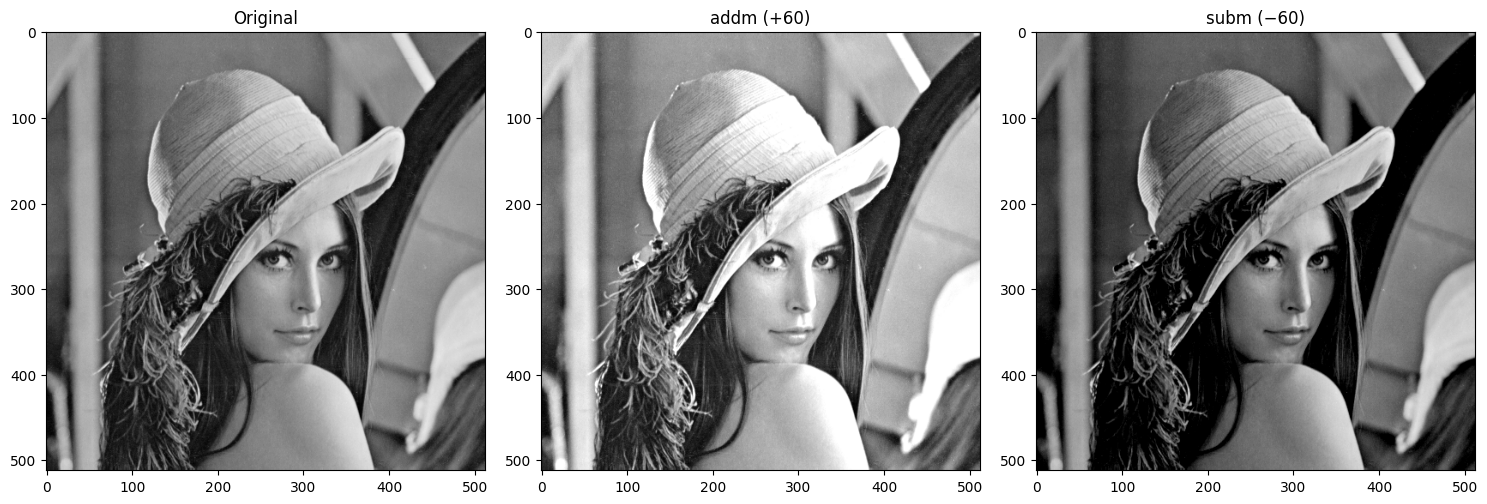

In [ ]:
#| label: fig-03-aritmetica
#| fig-cap: "Operações aritméticas saturadas: adição de constante (clareamento) e subtração de constante (escurecimento com saturação em 0)."
#| echo: true
#| output: true

fundo = 60

img_add = mm.addm(img_gray, fundo)
img_sub = mm.subm(img_gray, fundo)

mm.show(
    [img_gray, img_add, img_sub],
    titles=["Original", "addm (+60)", "subm (−60)"],
    cols=3
)

### Mistura Ponderada (*Alpha Blending*)

A **mistura ponderada** combina duas imagens com pesos complementares $\alpha$ e $(1-\alpha)$:

$$
g(x,y) = \alpha\,f_1(x,y) + (1-\alpha)\,f_2(x,y), \quad \alpha \in [0,1]
$$ {#eq-03-blend}

Para $\alpha = 1$ obtém-se $f_1$ pura; para $\alpha = 0$, $f_2$ pura. Valores intermediários produzem uma fusão proporcional — útil em sobreposição de camadas, marcas d'água e transições suaves entre cenas.

Para que o *blending* seja visualmente coerente, é essencial alinhar as regiões de interesse das duas imagens antes de combiná-las. Na @fig-03-blend, recorta-se o rosto da Lena (`img_gray[100:-70, 220:-120]`) e a região dos olhos do leopardo de @fig-03-natureza (`img_numpy[250:-300, 100:-200]`), de forma que os olhares fiquem sobrepostos. O leopardo é então redimensionado para coincidir com o tamanho do recorte da Lena. A operação é realizada em `float32` para evitar *overflow*, com *clipping* final para `uint8`.

GPS Decimal: -19.140200, 23.814872
Maps: https://www.google.com/maps/search/?api=1&query=-19.1402,23.814872222222224

Tipo PIL: <class 'PIL.JpegImagePlugin.JpegImageFile'> | Dimensões (x,y): (1242, 1324)
Pillow (0,0) (x,y): (191, 135, 88)
Tipo NumPy: <class 'numpy.ndarray'> | Dimensões [y,x,c]: (1324, 1242, 3)
NumPy [0,0] [y,x]: [191 135  88]


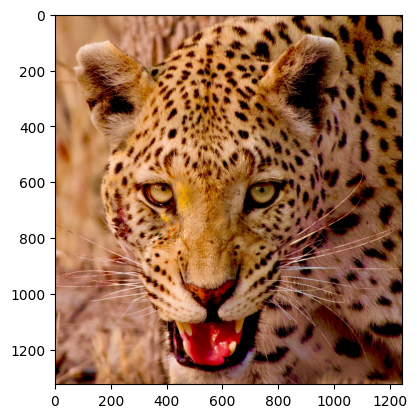

In [ ]:
#| label: fig-03-natureza
#| fig-cap: "Leopard (Panthera pardus) GPS: (-19.14020, 23.81487). Crédito: C. Brück (CC BY-SA 4.0)."
#| echo: true

from PIL.ExifTags import TAGS
import numpy as np

base = "https://upload.wikimedia.org/wikipedia/commons"

arquivo = "Leopard_%28Panthera_pardus%29_portrait.jpg"

url = f"{base}/9/92/{arquivo}"

# 1. Leitura com metadados (PIL) e conversão para matriz (NumPy)
img_obj   = mm.read(url, info=True)
img_numpy = np.array(img_obj)

# 2. Extração e conversão de GPS (Tag 34853)
exif = img_obj._getexif()
if exif and (gps := exif.get(34853)):
    to_dec = lambda dms, ref: float(
        -(dms[0] + dms[1]/60 + dms[2]/3600) if ref in 'SW'
        else (dms[0] + dms[1]/60 + dms[2]/3600)
    )
    lat, lon = to_dec(gps[2], gps[1]), to_dec(gps[4], gps[3])
    print(f"GPS Decimal: {lat:.6f}, {lon:.6f}")
    print(f"Maps: https://www.google.com/maps/search/?api=1&query={lat},{lon}")

# 3. Diagnóstico de tipos, dimensões e acesso a pixels
print(f"\nTipo PIL: {type(img_obj)} | Dimensões (x,y): {img_obj.size}")
print(f"Pillow (0,0) (x,y): {img_obj.getpixel((0, 0))}")

print(f"Tipo NumPy: {type(img_numpy)} | Dimensões [y,x,c]: {img_numpy.shape}")
print(f"NumPy [0,0] [y,x]: {img_numpy[0, 0]}")

# 4. Exibição
mm.show(img_obj)

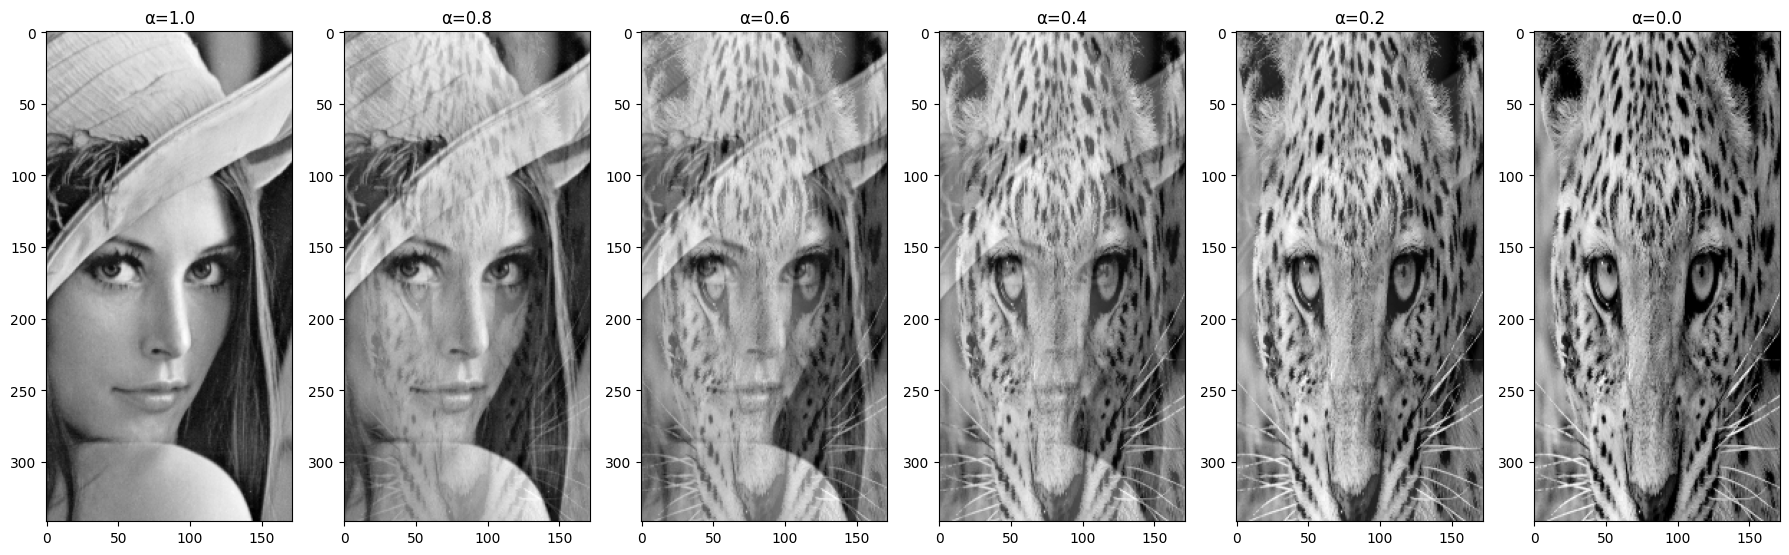

In [ ]:
#| label: fig-03-blend
#| fig-cap: "*Alpha blending* entre recortes alinhados de Lena e do leopardo (@fig-03-natureza) para diferentes valores de α. Em α=1 vê-se apenas Lena; em α=0, apenas o leopardo; valores intermediários fundem os olhares das duas imagens proporcionalmente."
#| echo: true
#| output: true

leo = mm.gray(img_numpy)
leo = leo[250:-300, 100:-200]
lena = img_gray[100:-70, 220:-120]
img_leopardo = mm.resize(leo, (lena.shape[1], lena.shape[0]), method='bilinear')

alphas = [1.0, 0.8, 0.6, 0.4, 0.2, 0.0]
imgs_blend   = []
titles_blend = []

for a in alphas:
    imgs_blend.append(mm.blend(lena, img_leopardo, alpha=a))
    titles_blend.append(f"α={a:.1f}")

mm.show(imgs_blend, titles=titles_blend, cols=6, figsize=(18, 16))

### Operações Lógicas e Máscaras Bit a Bit

As operações lógicas bit a bit (AND, OR e NOT) atuam diretamente sobre os bits de cada pixel e são a base para criação e aplicação de **máscaras** (*masks*) — imagens binárias com apenas 0 (preto) e 255 (branco) usadas para isolar Regiões de Interesse (ROI).

O comportamento de cada operação decorre da representação binária do 255 (`11111111`) e do 0 (`00000000`):

- **AND** com a máscara: onde $m = 255$, os bits originais são preservados; onde $m = 0$, o pixel é zerado. Resultado: recorte da ROI.
$$g(x,y) = f(x,y) \;\text{AND}\; m(x,y)
$$ {#eq-03-mascara}
- **OR** com a máscara: onde $m = 255$, o pixel é forçado a branco; onde $m = 0$, o valor original é mantido. Resultado: iluminação da ROI.
- **NOT** (sem máscara): inverte todos os bits ($g = 255 - f$), produzindo o negativo fotográfico da imagem.

A @fig-03-logica ilustra as três operações aplicadas à imagem Lena com uma máscara circular.

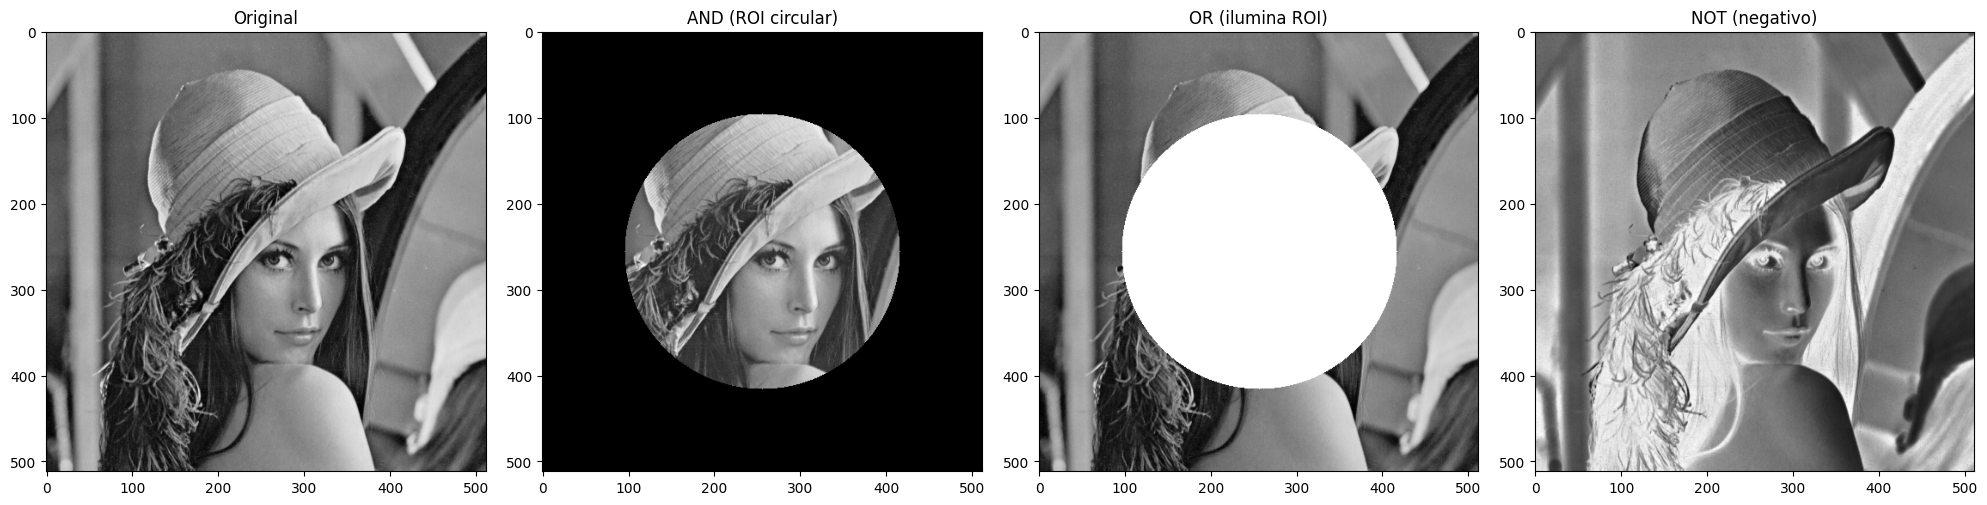

In [ ]:
#| label: fig-03-logica
#| fig-cap: "Operações lógicas bit a bit com máscara circular: NOT (negativo), AND (isolamento da ROI) e OR (iluminação da ROI)."
#| echo: true
#| output: true

h, w = img_gray.shape

# Máscara circular centrada na imagem
mask_circ = np.zeros((h, w), dtype=np.uint8)
cv2.circle(mask_circ, (w//2, h//2), min(h, w)//3 - 10, 255, -1)

# Operações via morph
img_not = mm.bnot(img_gray)                  # NOT: negativo fotográfico
img_and = mm.band(img_gray, mask_circ)       # img_gray & mask_circ: preserva apenas a ROI circular
img_or  = mm.bor(img_gray, mask_circ)        # img_gray | mask_circ: ilumina a região da máscara

mm.show(
    [img_gray, img_and, img_or, img_not],
    titles=["Original", "AND (ROI circular)", "OR (ilumina ROI)", "NOT (negativo)"],
    cols=4
)

## Histograma de Imagens

O **histograma** de uma imagem em tons de cinza é uma função discreta que descreve a distribuição de frequências das intensidades:

$$
h(r_k) = n_k, \quad k = 0, 1, \ldots, L-1
$$ {#eq-03-histograma}

onde $r_k$ é o $k$-ésimo nível de intensidade, $n_k$ é o número de pixels com essa intensidade e $L$ é o total de níveis (tipicamente 256 para 8 bits). O histograma normalizado estima a probabilidade de cada nível:

$$
p(r_k) = \frac{n_k}{MN}
$$ {#eq-03-hist-norm}

onde $MN$ é o total de pixels. Por ser uma **estatística global**, o histograma não carrega informação posicional, mas revela características essenciais como brilho médio, contraste e distribuição tonal. Na prática, `mm.hist(img)` retorna o vetor de contagens $h(r_k)$, que serve tanto para visualização (via `mm.histImg`) quanto para cálculos como CDF e equalização.

::: {.callout-note}
### Interpretação do Histograma {.unnumbered}
- **Estreito à esquerda:** imagem subexposta (escura).
- **Estreito à direita:** imagem superexposta (clara).
- **Concentrado no centro:** baixo contraste.
- **Distribuído por toda a faixa:** alto contraste, boa utilização dos tons disponíveis.
:::

A @fig-03-histograma exibe o histograma da imagem Lena, de uma versão escurecida (`mm.subm`) e de uma versão clareada (`mm.addm`), evidenciando o deslocamento da distribuição para a esquerda e para a direita, respectivamente.

In [ ]:
import morph
importlib.reload(morph)
from morph import mm

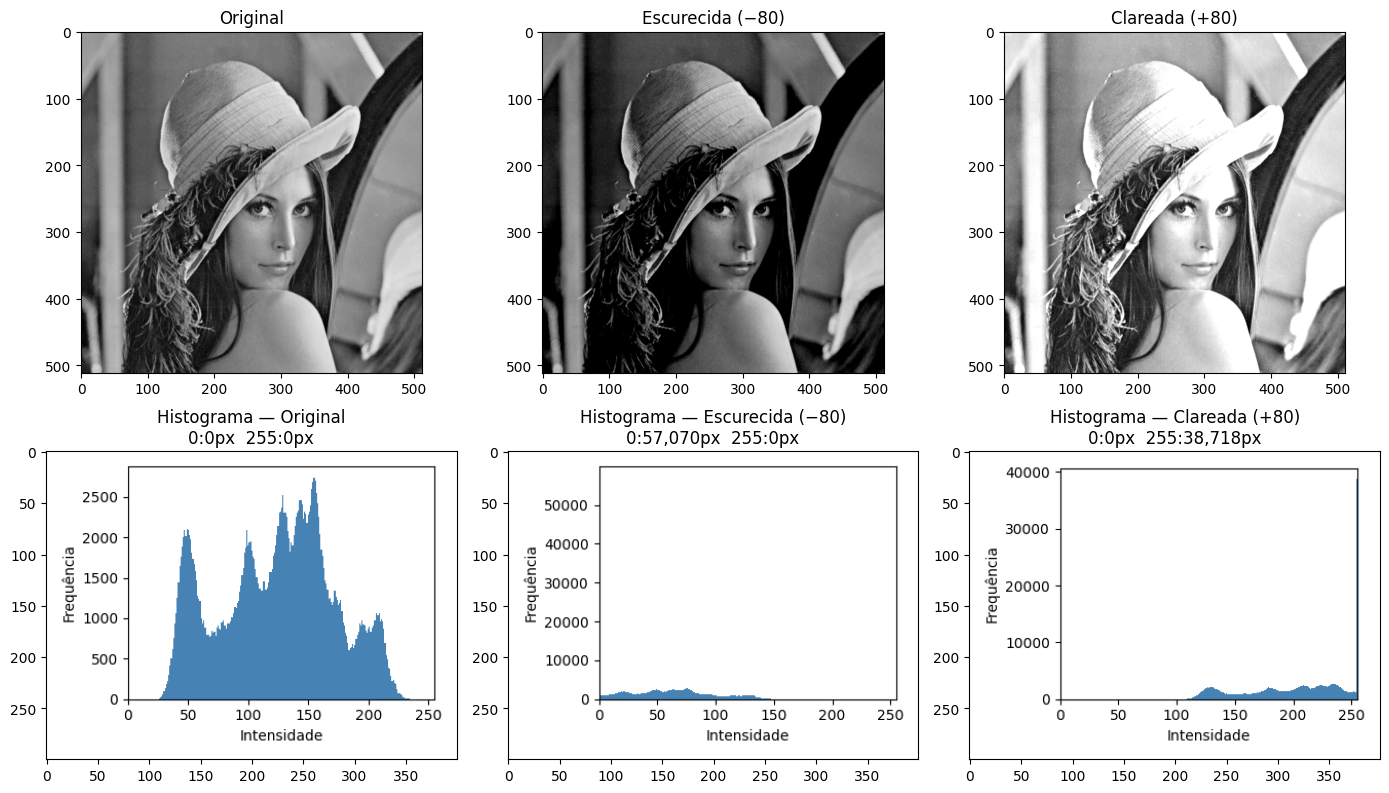

In [ ]:
#| label: fig-03-histograma
#| fig-cap: "Histogramas da imagem original, de uma versão escurecida e de uma versão clareada. Os valores entre parênteses indicam a quantidade de pixels saturados em 0 (preto) e 255 (branco)."
#| echo: true
#| output: true

img_dark = mm.subm(img_gray, 80)
img_high = mm.addm(img_gray, 80)

images = [img_gray, img_dark, img_high]
titles = ["Original", "Escurecida (−80)", "Clareada (+80)"]

def hist_title(img, t):
    H = mm.hist(img)
    n0  = int(H[0])
    n255 = int(H[255]) if len(H) > 255 else 0
    return f"Histograma — {t}\n0:{n0:,}px  255:{n255:,}px"

mm.show(
    images + [mm.histImg(img) for img in images],
    titles=titles + [hist_title(img, t) for img, t in zip(images, titles)],
    rows=2, cols=3,
    figsize=(14, 8)
)

### Equalização de Histograma

A **equalização de histograma** é uma técnica automática de realce de contraste que redistribui as intensidades para que o histograma resultante seja o mais uniforme possível. O mapeamento é realizado pela **função de distribuição acumulada (CDF)**:

$$
s_k = T(r_k) = (L-1)\sum_{j=0}^{k} p(r_j) = \frac{(L-1)}{MN}\sum_{j=0}^{k} n_j
$$ {#eq-03-equalizacao}

Essa transformação é monotônica e garante que os níveis de saída sejam distribuídos mais uniformemente, melhorando o contraste global sem intervenção manual do usuário.

**Limitação:** a equalização global pode super-realçar ruídos em regiões homogêneas. A técnica **CLAHE** (*Contrast Limited Adaptive Histogram Equalization*) resolve isso aplicando a equalização em blocos locais com limitação do *clip* de contraste.

A @fig-03-equalizacao compara a equalização global e o CLAHE.

In [ ]:
#| label: fig-03-equalizacao
#| fig-cap: "Equalização de histograma: global (OpenCV) vs. CLAHE (adaptativa com limitação de contraste). Observe o melhor contraste local com CLAHE sem artefatos excessivos."
#| echo: true
#| output: true

# Equalização global
img_eq = cv2.equalizeHist(img_gray)

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_gray)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

images = [img_gray, img_eq, img_clahe]
titles = ["Original", "Equalização Global", "CLAHE"]

for col, (img, title) in enumerate(zip(images, titles)):
    axes[0, col].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(title)
    axes[0, col].axis("off")
    axes[1, col].hist(img.ravel(), bins=256, range=(0, 256), color="steelblue", edgecolor="none")
    axes[1, col].set_xlim(0, 255)
    axes[1, col].set_xlabel("Intensidade")
    axes[1, col].set_title(f"Histograma — {title}")

plt.tight_layout()
plt.show()

### Especificação de Histograma

Enquanto a equalização impõe uma distribuição uniforme, a **especificação de histograma** (*histogram matching*) permite que o histograma da imagem de saída siga uma distribuição **arbitrária** pré-definida — por exemplo, a distribuição de outra imagem de referência.

O procedimento envolve três etapas:

1. Calcular a CDF da imagem de entrada: $P_r(r_k)$.
2. Calcular a CDF do histograma alvo: $P_z(z_k)$.
3. Determinar o mapeamento $T$ tal que $P_z(T(r_k)) = P_r(r_k)$, encontrando para cada $s_k = P_r(r_k)$ o nível $z$ que minimiza $|P_z(z) - s_k|$.

Na @fig-03-especificacao, aplicamos a especificação para que a imagem Lena assuma o perfil tonal de uma distribuição Gaussiana centrada em 180 (simulando uma imagem mais clara e suave), comparando com a equalização padrão.

In [ ]:
#| label: fig-03-especificacao
#| fig-cap: "Especificação de histograma: mapeamento da imagem Lena para uma distribuição Gaussiana alvo (μ=180, σ=40), comparada à equalização global."
#| echo: true
#| output: true

def hist_specify(img, target_hist):
    """Aplica especificação de histograma dado um histograma alvo normalizado."""
    # CDF da imagem de entrada
    hist_src, _ = np.histogram(img.ravel(), 256, [0, 256])
    cdf_src = hist_src.cumsum()
    cdf_src = cdf_src / cdf_src[-1]  # normaliza

    # CDF do alvo
    cdf_tgt = target_hist.cumsum()
    cdf_tgt = cdf_tgt / cdf_tgt[-1]

    # Mapeamento: para cada valor src, encontra o valor tgt de CDF mais próxima
    lut = np.searchsorted(cdf_tgt, cdf_src)
    return lut[img].astype(np.uint8)

# Histograma alvo: Gaussiana centrada em 180
x = np.arange(256)
mu, sigma = 180, 40
target = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
target = target / target.sum()

img_spec = hist_specify(img_gray, target)
img_eq   = cv2.equalizeHist(img_gray)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
images = [img_gray, img_eq, img_spec]
titles = ["Original", "Equalização Global", "Especificação (Gaussiana, μ=180)"]

for col, (img, title) in enumerate(zip(images, titles)):
    axes[0, col].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(title)
    axes[0, col].axis("off")
    axes[1, col].hist(img.ravel(), bins=256, range=(0, 256), color="steelblue", edgecolor="none")
    axes[1, col].set_xlim(0, 255)
    axes[1, col].set_xlabel("Intensidade")
    axes[1, col].set_title(f"Histograma — {title}")

plt.tight_layout()
plt.show()

## Fundamentos Espaciais: Vizinhança, Convolução e Kernels

As operações de filtragem espacial operam sobre **regiões vizinhas** de pixels — não mais pixel a pixel. O conceito central é a **janela deslizante** (*sliding window*): um *kernel* (também chamado de máscara ou filtro) percorre toda a imagem, e para cada posição $(x,y)$ calcula uma nova intensidade combinando os pixels da vizinhança ponderados pelos coeficientes do *kernel*.

### Convolução e Correlação

Existem dois mecanismos matematicamente relacionados:

**Correlação cruzada** (*cross-correlation*):

$$
g(x,y) = \sum_{s=-a}^{a}\sum_{t=-b}^{b} w(s,t)\,f(x+s,\,y+t)
$$ {#eq-03-correlacao}

**Convolução bidimensional**:

$$
g(x,y) = \sum_{s=-a}^{a}\sum_{t=-b}^{b} w(s,t)\,f(x-s,\,y-t)
$$ {#eq-03-convolucao}

A diferença é a **rotação de 180°** do *kernel* na convolução em relação à correlação. Para *kernels* simétricos (como Gaussiano, Laplaciano e de média), as duas operações produzem resultados idênticos. Para *kernels* assimétricos (como Sobel), a diferença é significativa.

::: {.callout-note}
### Correlação vs. Convolução no OpenCV {.unnumbered}
A função `cv2.filter2D` implementa **correlação** (não convolução). Para obter convolução verdadeira com um *kernel* assimétrico, rotacione o *kernel* 180° antes de passar para `filter2D`, ou use `scipy.ndimage.convolve`.
:::

### O Papel do *Kernel*

O *kernel* $w$ de dimensão $(2a+1) \times (2b+1)$ codifica a operação desejada:

| Operação | Efeito sobre o *kernel* |
|:---------|:------------------------|
| Soma = 1, coefs. positivos | Suavização (passa-baixa) |
| Soma = 0, coefs. positivos e negativos | Detecção de bordas (passa-alta) |
| Soma = 1, centro > 1, bordas < 0 | Realce de nitidez |
| Valor absoluto da diferença | Gradiente direcional |

: Interpretação dos coeficientes do *kernel* em filtros espaciais. {#tbl-03-kernels}

A @fig-03-convolucao-passo ilustra o mecanismo de convolução passo a passo em uma pequena matriz.

In [ ]:
#| label: fig-03-convolucao-passo
#| fig-cap: "Visualização do mecanismo de convolução: o kernel 3×3 de média percorre a imagem Lena (à esquerda) gerando a saída suavizada (à direita). Os valores mostram o kernel normalizado e o resultado central da primeira aplicação."
#| echo: true
#| output: true

# Demonstração manual: convolução em um patch 5x5
patch = img_gray[250:255, 250:255].astype(np.float32)
kernel_mean = np.ones((3, 3), dtype=np.float32) / 9.0

print("Patch 5×5 original (intensidades):")
print(patch.astype(np.int32))

# Aplicação manual no pixel central (2,2)
roi = patch[0:3, 0:3]  # vizinhança 3×3
resultado = np.sum(roi * kernel_mean)
print(f"\nKernel 3×3 de média:\n{kernel_mean}")
print(f"\nConvolução no pixel central: {resultado:.1f} (original: {patch[1,1]:.0f})")

# Aplicação completa com filter2D
img_conv = cv2.filter2D(img_gray, -1, kernel_mean)
mm.show([img_gray, img_conv],
        titles=["Original", "Após Convolução (kernel média 3×3)"],
        cols=2)

## Filtragem Espacial de Suavização

Os filtros de suavização (*smoothing filters*) atenuam variações bruscas de intensidade, reduzindo ruído e detalhes de alta frequência. São filtros **passa-baixa** — preservam as componentes de baixa frequência (estruturas grandes) e atenuam as de alta frequência (ruído, bordas).

### Filtro de Média (*Box Filter*)

O filtro de média mais simples utiliza um *kernel* uniforme de tamanho $n \times n$:

$$
w_{\text{média}} = \frac{1}{n^2}
\begin{bmatrix}
1 & \cdots & 1 \\
\vdots & \ddots & \vdots \\
1 & \cdots & 1
\end{bmatrix}_{n \times n}
$$ {#eq-03-media}

Cada pixel de saída é a média aritmética dos pixels de sua vizinhança $n \times n$. Kernels maiores produzem suavização mais agressiva, mas borram mais as bordas.

A @fig-03-media compara o efeito de kernels de média com diferentes tamanhos.

In [ ]:
#| label: fig-03-media
#| fig-cap: "Filtro de média com kernels de tamanho crescente (3×3, 7×7, 15×15). Observe o crescente borramento das bordas com o aumento do tamanho do kernel."
#| echo: true
#| output: true

sizes = [3, 7, 15]
imgs_media = []
titles_media = ["Original"]

for k in sizes:
    kernel = np.ones((k, k), dtype=np.float32) / (k * k)
    imgs_media.append(cv2.filter2D(img_gray, -1, kernel))
    titles_media.append(f"Média {k}×{k}")

mm.show([img_gray] + imgs_media, titles=titles_media, cols=4)

### Filtro Gaussiano

O filtro Gaussiano pesa os pixels da vizinhança de acordo com uma função Gaussiana bidimensional:

$$
G(s,t) = \frac{1}{2\pi\sigma^2}\,e^{-\frac{s^2+t^2}{2\sigma^2}}
$$ {#eq-03-gaussiana}

onde $\sigma$ é o desvio padrão e controla o raio de influência. Pixels mais próximos do centro têm peso maior; pixels distantes são progressivamente ignorados. Comparado ao filtro de média, o Gaussiano:

- Preserva melhor as bordas (borramento mais suave e gradual);
- É separável: $G(s,t) = G(s)\cdot G(t)$, permitindo implementação eficiente em duas passagens 1D;
- É o único filtro que não introduz anéis (*ringing*) na frequência.

A @fig-03-gauss compara média e Gaussiano no detalhe da imagem, evidenciando a preservação de bordas.

In [ ]:
#| label: fig-03-gauss
#| fig-cap: "Comparação entre filtro de média e Gaussiano (ambos com janela 9×9). O Gaussiano suaviza com menos borramento das bordas, visível no detalhe do olho."
#| echo: true
#| output: true

# Filtro de média 9x9
kernel9 = np.ones((9, 9), dtype=np.float32) / 81.0
img_media9 = cv2.filter2D(img_gray, -1, kernel9)

# Filtro Gaussiano 9x9
img_gauss9 = cv2.GaussianBlur(img_gray, (9, 9), 0)

# Recorte do olho para comparação de detalhes
y, x, off = 265, 265, 40
crop_orig  = img_gray[y-off:y+off, x-off:x+off]
crop_media = img_media9[y-off:y+off, x-off:x+off]
crop_gauss = img_gauss9[y-off:y+off, x-off:x+off]

# Ampliação para visualização
amp = lambda c: mm.resize(c, 3, method="nearest")

mm.show(
    [img_gray, img_media9, img_gauss9,
     amp(crop_orig), amp(crop_media), amp(crop_gauss)],
    titles=["Original", "Média 9×9", "Gaussiano 9×9",
            "Detalhe: Original", "Detalhe: Média", "Detalhe: Gaussiano"],
    cols=3
)

## Filtragem Espacial de Realce

Os filtros de realce (*sharpening filters*) enfatizam transições abruptas de intensidade, aumentando a nitidez e a visibilidade de bordas. São filtros **passa-alta** — amplificam as componentes de alta frequência (bordas, textura) e suprimem as de baixa frequência (regiões uniformes).

### Laplaciano

O Laplaciano é um operador de segunda derivada que responde a variações bruscas em todas as direções:

$$
\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}
$$ {#eq-03-laplaciano}

Na forma discreta, aproxima-se por um *kernel* 3×3. Existem duas variantes comuns:

$$
w_4 = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}, \qquad
w_8 = \begin{bmatrix} 1 & 1 & 1 \\ 1 & -8 & 1 \\ 1 & 1 & 1 \end{bmatrix}
$$ {#eq-03-laplaciano-kernel}

A imagem realçada é obtida somando o Laplaciano à original (com sinal negativo quando o centro do *kernel* é negativo):

$$
g(x,y) = f(x,y) - \nabla^2 f(x,y)
$$ {#eq-03-realce-lap}

A @fig-03-laplaciano ilustra a resposta do Laplaciano e a imagem realçada.

In [ ]:
#| label: fig-03-laplaciano
#| fig-cap: "Realce com Laplaciano: (esq.) imagem original, (centro) resposta do Laplaciano (bordas detectadas), (dir.) imagem realçada pela subtração do Laplaciano."
#| echo: true
#| output: true

# Kernel Laplaciano 4-vizinhos
kernel_lap = np.array([[0, 1, 0],
                        [1,-4, 1],
                        [0, 1, 0]], dtype=np.float32)

# Aplicar Laplaciano
img_f32 = img_gray.astype(np.float32)
lap = cv2.filter2D(img_f32, cv2.CV_32F, kernel_lap)

# Realce: subtrai o Laplaciano (centro negativo → subtrai → realça)
img_realce = np.clip(img_f32 - lap, 0, 255).astype(np.uint8)

# Laplaciano normalizado para visualização
lap_viz = np.clip(np.abs(lap) / np.abs(lap).max() * 255, 0, 255).astype(np.uint8)

mm.show(
    [img_gray, lap_viz, img_realce],
    titles=["Original", "Laplaciano (bordas)", "Realce (f - ∇²f)"],
    cols=3
)

### Operador de Sobel

O operador de Sobel estima as derivadas parciais de primeira ordem da imagem nas direções horizontal e vertical, usando *kernels* que combinam suavização Gaussiana com derivada direcional:

$$
G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix} * f, \qquad
G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix} * f
$$ {#eq-03-sobel}

A magnitude do **gradiente** combina os dois componentes e representa a força da borda em cada ponto:

$$
|\nabla f| = \sqrt{G_x^2 + G_y^2}
$$ {#eq-03-gradiente}

A **direção** do gradiente, perpendicular à borda, é:

$$
\theta = \arctan\left(\frac{G_y}{G_x}\right)
$$ {#eq-03-direcao}

A @fig-03-sobel mostra os componentes direcionais e a magnitude do gradiente para a imagem Lena.

In [ ]:
#| label: fig-03-sobel
#| fig-cap: "Operador de Sobel: componentes horizontal (Gx), vertical (Gy) e magnitude do gradiente. As bordas são regiões de alta magnitude."
#| echo: true
#| output: true

sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
magnitude = np.sqrt(sobelx**2 + sobely**2)

# Normalização para visualização
def norm255(img):
    mn, mx = img.min(), img.max()
    return ((img - mn) / (mx - mn + 1e-9) * 255).astype(np.uint8)

mm.show(
    [img_gray, norm255(np.abs(sobelx)), norm255(np.abs(sobely)), norm255(magnitude)],
    titles=["Original", "Sobel Gx (horizontal)", "Sobel Gy (vertical)", "Magnitude |∇f|"],
    cols=4
)

### *Unsharp Masking* (USM)

O *Unsharp Masking* é uma técnica clássica de realce de nitidez originária da fotografia analógica, hoje amplamente usada em software de edição de imagens. O processo é:

1. **Suavizar** a imagem original: $\bar{f} = f * G_\sigma$ (convolução com Gaussiana);
2. **Calcular a máscara não-nitida**: $m(x,y) = f(x,y) - \bar{f}(x,y)$ (componentes de alta frequência);
3. **Somar a máscara ponderada**: $g(x,y) = f(x,y) + k \cdot m(x,y)$.

$$
g = f + k\,(f - f*G_\sigma) = (1+k)f - k\,(f*G_\sigma)
$$ {#eq-03-usm}

O parâmetro $k$ controla a intensidade do realce: $k=1$ corresponde ao USM clássico; $k>1$ produz *high boost filtering*. A @fig-03-usm compara diferentes valores de $k$.

In [ ]:
#| label: fig-03-usm
#| fig-cap: "Unsharp Masking com diferentes fatores k: k=0.5 (suave), k=1.0 (clássico) e k=2.0 (High Boost). Maior k aumenta a nitidez mas também amplifica ruídos."
#| echo: true
#| output: true

def unsharp_mask(img, sigma=2.0, k=1.0):
    """Aplica Unsharp Masking com parâmetro de realce k."""
    ksize = int(6 * sigma + 1) | 1  # garante tamanho ímpar
    suav  = cv2.GaussianBlur(img.astype(np.float32), (ksize, ksize), sigma)
    mask  = img.astype(np.float32) - suav
    return np.clip(img.astype(np.float32) + k * mask, 0, 255).astype(np.uint8)

ks = [0.5, 1.0, 2.0]
imgs_usm = [unsharp_mask(img_gray, sigma=2.0, k=k) for k in ks]
titles_usm = [f"USM k={k}" for k in ks]

mm.show(
    [img_gray] + imgs_usm,
    titles=["Original"] + titles_usm,
    cols=4
)

## Filtros de Ordem: Filtro da Mediana

Os filtros de ordem (*order-statistic filters*) substituem o pixel central pelo valor de um **percentil** da distribuição de intensidades da vizinhança — ao contrário dos filtros lineares, que calculam combinações ponderadas. O mais importante é o **filtro da mediana**.

### Ruído Impulsivo: Sal e Pimenta

O ruído **sal e pimenta** (*salt-and-pepper noise*) é um tipo de ruído impulsivo que substitui pixels aleatórios por valores extremos: 0 (pimenta) ou 255 (sal). É comum em transmissão de imagens com erros de bit e em câmeras com sensores defeituosos.

::: {.callout-warning}
### Por que filtros de média falham com ruído impulsivo? {.unnumbered}
Um único pixel com valor 255 em uma vizinhança de 9 pixels com valor ≈ 100 eleva a média para ≈ 128, espalhando o ruído. A mediana, por ser um **estimador robusto**, ignora os valores extremos ao selecionar o valor central da distribuição ordenada.
:::

O experimento na @fig-03-ruido demonstra a adição de ruído sal e pimenta com diferentes densidades.

In [ ]:
#| label: fig-03-ruido
#| fig-cap: "Ruído sal e pimenta com densidades crescentes (2%, 5%, 10%). O parâmetro prob indica a fração de pixels corrompidos."
#| echo: true
#| output: true

def add_salt_pepper(img, prob=0.05):
    """Adiciona ruído sal e pimenta com probabilidade total prob."""
    noisy = img.copy()
    rnd   = np.random.default_rng(42).random(img.shape)
    noisy[rnd < prob / 2]      = 0    # pimenta (preto)
    noisy[rnd > 1 - prob / 2]  = 255  # sal (branco)
    return noisy

probs = [0.02, 0.05, 0.10]
imgs_noise = [add_salt_pepper(img_gray, p) for p in probs]
titles_noise = [f"Ruído: {int(p*100)}%" for p in probs]

mm.show([img_gray] + imgs_noise, titles=["Original"] + titles_noise, cols=4)

### Filtro da Mediana

O filtro da mediana substitui cada pixel pelo **valor mediano** dos pixels da sua vizinhança $n \times n$:

$$
g(x,y) = \text{med}_{(s,t) \in \mathcal{V}_{n}} \{f(x+s, y+t)\}
$$ {#eq-03-mediana}

O valor mediano é aquele que ocupa a posição central quando os $n^2$ valores da vizinhança são ordenados. Por ser baseado em ordenação e não em soma, a mediana é:

- **Robusta** ao ruído impulsivo (ignora valores extremos);
- **Preservadora de bordas** (não borra transições abruptas como o filtro de média);
- **Não linear** (não pode ser expressa como convolução).

A @fig-03-mediana compara a eficiência do filtro de média e da mediana na remoção de ruído sal e pimenta.

In [ ]:
#| label: fig-03-mediana
#| fig-cap: "Comparação entre filtro de média e mediana para remoção de ruído sal e pimenta (densidade 5%). A mediana remove o ruído preservando bordas; a média espalha os pixels corrompidos."
#| echo: true
#| output: true

img_noise5 = add_salt_pepper(img_gray, prob=0.05)

# Filtro de média 3x3
kernel3 = np.ones((3, 3), dtype=np.float32) / 9.0
img_media_dn  = cv2.filter2D(img_noise5, -1, kernel3)

# Filtro da mediana 3x3 e 5x5
img_med3 = cv2.medianBlur(img_noise5, 3)
img_med5 = cv2.medianBlur(img_noise5, 5)

mm.show(
    [img_gray, img_noise5, img_media_dn, img_med3, img_med5],
    titles=["Original", "Ruído 5%", "Média 3×3", "Mediana 3×3", "Mediana 5×5"],
    cols=5
)

## Aplicação Prática: Pré-processamento para Segmentação

Na prática, as técnicas deste capítulo raramente são usadas isoladamente. Um **pipeline de pré-processamento** típico combina várias etapas em sequência, adaptando-se ao tipo de imagem e à aplicação. A @fig-03-pipeline ilustra um pipeline completo:

1. **Equalização de histograma (CLAHE):** normaliza o contraste independente das condições de iluminação;
2. **Filtro Gaussiano:** suaviza ruído de aquisição sem destruir bordas;
3. **Detecção de bordas (Sobel/Canny):** extrai estruturas relevantes para segmentação.

::: {.callout-note}
### Ordem importa {.unnumbered}
A ordem das operações afeta o resultado final. Em geral: **(1) normalização de intensidade → (2) redução de ruído → (3) realce/segmentação**. Inverter a ordem pode amplificar ruído ou perder bordas antes de detectá-las.
:::

In [ ]:
#| label: fig-03-pipeline
#| fig-cap: "Pipeline de pré-processamento: CLAHE → Gaussiano → Canny. Cada etapa prepara a imagem para a seguinte, resultando em bordas limpas e bem definidas."
#| echo: true
#| output: true

# Etapa 1: CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_gray)

# Etapa 2: Gaussiano
img_gauss = cv2.GaussianBlur(img_clahe, (5, 5), 0)

# Etapa 3: Canny
edges = cv2.Canny(img_gauss, 50, 150)

# Comparação: pipeline vs. Canny direto
edges_direct = cv2.Canny(img_gray, 50, 150)

mm.show(
    [img_gray, img_clahe, img_gauss, edges, edges_direct],
    titles=["Original", "1. CLAHE", "2. Gaussiano", "3. Canny (pipeline)", "Canny (direto)"],
    cols=5
)

## Resumo

Neste capítulo foram apresentadas as principais técnicas de processamento no domínio espacial:

- **Operações de ponto:** transformações aritméticas (adição, subtração, blending) e lógicas (AND, OR, NOT) para manipulação direta de pixels.
- **Histograma:** ferramenta diagnóstica que descreve a distribuição de intensidades; base para equalização global e CLAHE (adaptativa).
- **Especificação de histograma:** transferência do perfil tonal de uma distribuição alvo usando o mapeamento pela CDF.
- **Convolução e correlação:** mecanismo de janela deslizante que implementa filtros lineares; diferenciados pela rotação do *kernel*.
- **Filtros de suavização:** média (uniforme) e Gaussiano (ponderado); o Gaussiano preserva melhor as bordas.
- **Filtros de realce:** Laplaciano (segunda derivada), Sobel (gradiente direcional) e *Unsharp Masking* (amplificação de alta frequência).
- **Filtro da mediana:** estimador robusto, não linear, eficiente contra ruído sal e pimenta com preservação de bordas.
- **Pipeline prático:** encadeamento de técnicas (CLAHE → Gaussiano → Canny) como estratégia de pré-processamento para aplicações reais.

O Capítulo 4 abordará o **processamento no domínio da frequência** (Transformada de Fourier) e a **morfologia matemática** (erosão, dilatação, abertura, fechamento).

## 🤖 Uso do NotebookLM como Tutor Complementar

Nesta edição, incentivamos o uso do **NotebookLM** como ferramenta complementar de aprendizagem. Essa ferramenta de IA utiliza exclusivamente os documentos fornecidos pelo autor como base de conhecimento, garantindo respostas coerentes com o conteúdo do livro.

Para cada capítulo, preparamos um projeto específico na plataforma. Para uma experiência de estudo ampliada, utilize o acesso abaixo:

::: {.callout-important appearance="default" icon=false}
### 🎓 Estude com o Tutor Inteligente {.unnumbered}

Para interagir com o conteúdo deste capítulo, acesse o link a seguir. O ambiente contém materiais didáticos em diferentes formatos, gerados a partir do **PDF** do capítulo. Na plataforma, explore especialmente as opções **Guia de Estudo** e **Conversa** para aprofundar sua compreensão.

[🚀 ACESSAR NOTEBOOKLM: CAPÍTULO 03](https://notebooklm.google.com/notebook/cap03)
:::

## Lista de Exercícios

1. **(10%)** Explique a diferença entre **convolução** e **correlação cruzada**. Para quais tipos de *kernel* os resultados são idênticos? Dê um exemplo de *kernel* onde as operações diferem.

2. **(15%)** Considere uma imagem com histograma fortemente concentrado entre os níveis 50 e 150. Descreva matematicamente o mapeamento que a equalização de histograma aplicaria. Calcule os novos níveis para $r = 50$, $r = 100$ e $r = 150$, assumindo que os pixels estão uniformemente distribuídos nesse intervalo.

3. **(15%)** Usando o código do laboratório, aplique o filtro de média com kernels de tamanho 3×3, 9×9 e 21×21. Compare quantitativamente os resultados calculando o **PSNR** (*Peak Signal-to-Noise Ratio*) entre a imagem original e cada versão filtrada. O que a queda do PSNR indica?

4. **(15%)** Adicione ruído sal e pimenta com densidade de 5% e aplique: (a) filtro de média 3×3, (b) filtro Gaussiano $\sigma=1$, (c) mediana 3×3 e (d) mediana 5×5. Compare visualmente e explique por que a mediana supera os filtros lineares nesse cenário.

5. **(15%)** Implemente manualmente (sem `cv2.filter2D`) a correlação cruzada de um *kernel* de média 3×3 em uma imagem de escala de cinza utilizando apenas operações NumPy vetorizadas (sem laços Python). Compare o resultado e o tempo de execução com a versão `cv2.filter2D`.

6. **(15%)** Aplique o *Unsharp Masking* com $\sigma = 1$ e $k = \{0.5, 1.0, 2.0, 4.0\}$. Para cada valor, calcule a diferença absoluta em relação à imagem original e exiba os histogramas dessas diferenças. O que acontece com os artefatos quando $k$ é muito alto?

7. **(15%)** Projete um pipeline de pré-processamento para uma imagem médica (raio-X, por exemplo) com objetivo de realçar estruturas internas. Justifique cada etapa escolhida com base nos conceitos do capítulo e demonstre o resultado.

## Referências do Capítulo {.unnumbered}

A fundamentação teórica deste capítulo baseia-se nas seguintes obras:

* @gonzalez2018digital para os conceitos de operações de intensidade, histograma, convolução e filtragem espacial.
* @szeliski2022 para a visão computacional e aplicações práticas de filtragem.
* @bradski2008learning para a implementação prática com OpenCV e `morph.py`.

---


[![](imagens/colab-badge.png){width="16%"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap03/cap03.EPs_aluno.ipynb)
[![](imagens/github-badge.png){width="20%"}](https://github.com/fzampirolli/pdi-vc)

## 💻 **Parte Prática com Exercícios de Programação**

---

### 🎯 Objetivo deste Caderno {.unnumbered}

O caderno permite desenvolver, validar, organizar e testar soluções de  **Exercícios de Programação (EPs)** em ambientes interativos, como o Colab, com os mesmos casos de teste do Moodle, copiando para lá apenas na hora de registrar a nota oficial.

#### Download {.unnumbered}

Baixe `morph.py` e `testsuite.py` executando a célula abaixo:

In [ ]:
import os, sys, importlib, inspect, urllib.request

# URLs do repositório
BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph"
for f in ["morph.py", "testsuite.py"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"{BASE_URL}/{f}", f)

import morph, testsuite
importlib.reload(morph); importlib.reload(testsuite)
from morph import mm
from testsuite import TestSuite

print(f"✅ Ambiente pronto. Morph: {morph.__version__} | TestSuite: {testsuite.__version__}")

✅ Ambiente pronto. Morph: 1.1.0 | TestSuite: 1.1.0


---

#### Executando os Testes {.unnumbered}

Para rodar os testes, execute `TestSuite("EP01_01.extensão").run()` numa nova célula, trocando a extensão pela da linguagem usada (`.py`, `.java`, `.c`, `.cpp`, `.js` ou `.r`). O sistema baixa os casos de teste do GitHub, executa o programa e calcula a nota automaticamente.

**Exemplo de teste de `sqrt` em Python, com `timeit` isolando cada operação:**

In [ ]:
#| label: fig-01-metricas-distancia
#| fig-cap: "Simulador: Distâncias Euclidiana, *City-block* e *Chessboard*"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
  <!-- SIMULADOR INTERATIVO (estilo integrado ao padrão) -->
  <div
    style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px;">
    <div
      style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
      <span>🎮 Simulador: arraste os pontos ou use os controles</span>
      <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">⚡ Euclidiana (√) ≈ mais custosa</span>
    </div>

    <!-- cards das 3 métricas (valores dinâmicos) -->
    <div style="display: grid; grid-template-columns: repeat(3,1fr); gap: 10px; padding: 16px 16px 8px 16px;">
      <div style="background: #efeefb; border-radius: 16px; padding: 10px 6px; text-align: center; border:1px solid #dad3f0;">
        <div style="font-size: 10px; font-weight: 800; text-transform: uppercase; color: #5849a8;">📐 Euclidiana (L2)</div>
        <div style="font-size: 28px; font-weight: 700; font-family: monospace; color: #5849a8;" id="dispE-sim">5.00</div>
        <div style="font-size: 9px; font-family: monospace;">√(Δx²+Δy²)</div>
      </div>
      <div style="background: #e6f4ed; border-radius: 16px; padding: 10px 6px; text-align: center; border:1px solid #cbe4d6;">
        <div style="font-size: 10px; font-weight: 800; text-transform: uppercase; color: #1a7a51;">🧱 City‑Block (L1)</div>
        <div style="font-size: 28px; font-weight: 700; font-family: monospace; color: #1a7a51;" id="dispC-sim">7.00</div>
        <div style="font-size: 9px; font-family: monospace;">|Δx|+|Δy|</div>
      </div>
      <div style="background: #feece2; border-radius: 16px; padding: 10px 6px; text-align: center; border:1px solid #f7d9c8;">
        <div style="font-size: 10px; font-weight: 800; text-transform: uppercase; color: #b35020;">🏁 Chessboard (L∞)</div>
        <div style="font-size: 28px; font-weight: 700; font-family: monospace; color: #b35020;" id="dispX-sim">4.00</div>
        <div style="font-size: 9px; font-family: monospace;">max(|Δx|,|Δy|)</div>
      </div>
    </div>

    <!-- canvas + controles -->
    <div style="display: flex; flex-wrap: wrap; gap: 16px; padding: 0 16px 16px 16px;">
      <div style="flex: 2; min-width: 200px;">
        <canvas id="simCanvasDist" width="380" height="280" style="display: block; width: 100%; height: auto; background: #fffef7; border-radius: 14px; border: 1px solid #e8dfcf; cursor: crosshair; touch-action: none;"></canvas>
        <div style="font-size: 9px; text-align: center; margin-top: 5px; color: #bcaf95;">👆 clique e arraste os pontos A (roxo) ou B (laranja)</div>
      </div>
      <div style="flex: 1.2; min-width: 160px; display: flex; flex-direction: column; gap: 12px;">
        <div style="background: #fefaf2; border-radius: 14px; border: 1px solid #ede2d2; padding: 10px;">
          <div style="font-size: 11px; font-weight: 700; display: flex; align-items: center; gap: 6px; margin-bottom: 8px;">
            <span style="display: inline-block; width: 9px; height: 9px; background: #826ed6; border-radius: 50%;"></span> Ponto A
          </div>
          <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 6px;">
            <label style="font-size: 11px; font-weight: 700; width: 22px;">Ax</label>
            <input type="number" id="axN" value="0" step="0.5" style="width: 54px; font-size: 11px; font-family: monospace; border:1px solid #ddd2be; border-radius:20px; padding:3px 6px;">
            <input type="range" id="axR" min="-7" max="7" value="0" step="0.5" style="flex:1; height:3px; accent-color:#9b8fef;">
          </div>
          <div style="display: flex; align-items: center; gap: 5px;">
            <label style="font-size: 11px; font-weight: 700; width: 22px;">Ay</label>
            <input type="number" id="ayN" value="0" step="0.5" style="width: 54px; font-size: 11px; font-family: monospace; border:1px solid #ddd2be; border-radius:20px; padding:3px 6px;">
            <input type="range" id="ayR" min="-7" max="7" value="0" step="0.5" style="flex:1; height:3px; accent-color:#9b8fef;">
          </div>
        </div>
        <div style="background: #fefaf2; border-radius: 14px; border: 1px solid #ede2d2; padding: 10px;">
          <div style="font-size: 11px; font-weight: 700; display: flex; align-items: center; gap: 6px; margin-bottom: 8px;">
            <span style="display: inline-block; width: 9px; height: 9px; background: #e0845c; border-radius: 50%;"></span> Ponto B
          </div>
          <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 6px;">
            <label style="font-size: 11px; font-weight: 700; width: 22px;">Bx</label>
            <input type="number" id="bxN" value="3" step="0.5" style="width: 54px; font-size: 11px; font-family: monospace; border:1px solid #ddd2be; border-radius:20px; padding:3px 6px;">
            <input type="range" id="bxR" class="rb" min="-7" max="7" value="3" step="0.5" style="flex:1; height:3px; accent-color:#d18f66;">
          </div>
          <div style="display: flex; align-items: center; gap: 5px;">
            <label style="font-size: 11px; font-weight: 700; width: 22px;">By</label>
            <input type="number" id="byN" value="4" step="0.5" style="width: 54px; font-size: 11px; font-family: monospace; border:1px solid #ddd2be; border-radius:20px; padding:3px 6px;">
            <input type="range" id="byR" class="rb" min="-7" max="7" value="4" step="0.5" style="flex:1; height:3px; accent-color:#d18f66;">
          </div>
        </div>
        <button id="resetBtnSim" style="background: #efe6da; border: none; border-radius: 40px; font-size: 11px; font-weight: 700; padding: 7px 0; cursor: pointer; width: 100%;">⟳ Reset (0,0) e (3,4)</button>
      </div>
    </div>
    <div style="font-size: 10px; text-align: center; padding: 8px 16px 12px; color: #ad9f86; border-top: 1px solid #f0e7db; background: #fdfaf5;">
      💡 O gráfico mostra: linha reta tracejada (Euclidiana), caminho em L (City‑Block) e o retângulo (Chessboard).<br>
      <span style="display: flex; gap: 12px; justify-content: center; margin-top: 4px;">
        <span style="display: inline-flex; align-items: center; gap: 4px;"><span style="display: inline-block; width: 18px; height: 2px; background: #826ed6;"></span> Euclidiana</span>
        <span style="display: inline-flex; align-items: center; gap: 4px;"><span style="display: inline-block; width: 18px; height: 2px; background: #4aaa7d;"></span> City‑Block</span>
        <span style="display: inline-flex; align-items: center; gap: 4px;"><span style="display: inline-block; width: 18px; height: 2px; background: #e0845c; border: 1px dashed;"></span> Chessboard</span>
      </span>
    </div>
  </div>


<!-- SCRIPT DO SIMULADOR (mesmo código funcional, apenas com ids adaptados) -->
<script>
  (function() {
    // Elementos do simulador
    const canvas = document.getElementById('simCanvasDist');
    const ctx = canvas.getContext('2d');
    const width = 380, height = 280;
    canvas.width = width; canvas.height = height;

    const axN = document.getElementById('axN'), axR = document.getElementById('axR');
    const ayN = document.getElementById('ayN'), ayR = document.getElementById('ayR');
    const bxN = document.getElementById('bxN'), bxR = document.getElementById('bxR');
    const byN = document.getElementById('byN'), byR = document.getElementById('byR');
    const dispE = document.getElementById('dispE-sim');
    const dispC = document.getElementById('dispC-sim');
    const dispX = document.getElementById('dispX-sim');
    const resetBtn = document.getElementById('resetBtnSim');

    // Intervalo do mundo
    const xMin = -6.5, xMax = 7.8;
    const yMin = -5.2, yMax = 7.2;

    function worldToCanvas(x, y) {
      const px = ((x - xMin) / (xMax - xMin)) * width;
      const py = height - ((y - yMin) / (yMax - yMin)) * height;
      return { x: px, y: py };
    }
    function canvasToWorld(px, py) {
      const x = xMin + (px / width) * (xMax - xMin);
      const y = yMin + ((height - py) / height) * (yMax - yMin);
      return { x, y };
    }

    function getVals() {
      return {
        ax: parseFloat(axN.value) || 0,
        ay: parseFloat(ayN.value) || 0,
        bx: parseFloat(bxN.value) || 0,
        by: parseFloat(byN.value) || 0
      };
    }

    function updateAll() {
      let { ax, ay, bx, by } = getVals();
      axR.value = ax; ayR.value = ay; bxR.value = bx; byR.value = by;
      const dx = bx - ax, dy = by - ay;
      const eucl = Math.hypot(dx, dy);
      const city = Math.abs(dx) + Math.abs(dy);
      const chess = Math.max(Math.abs(dx), Math.abs(dy));
      dispE.innerText = eucl.toFixed(2);
      dispC.innerText = city.toFixed(2);
      dispX.innerText = chess.toFixed(2);
      drawCanvas(ax, ay, bx, by);
    }

    function drawCanvas(ax, ay, bx, by) {
      ctx.clearRect(0, 0, width, height);
      ctx.lineWidth = 0.6;
      ctx.strokeStyle = "#e2dbc9";
      // grid
      for (let i = -6; i <= 8; i++) {
        const p1 = worldToCanvas(i, yMin), p2 = worldToCanvas(i, yMax);
        ctx.beginPath(); ctx.moveTo(p1.x, p1.y); ctx.lineTo(p2.x, p2.y); ctx.stroke();
        const p3 = worldToCanvas(xMin, i), p4 = worldToCanvas(xMax, i);
        ctx.beginPath(); ctx.moveTo(p3.x, p3.y); ctx.lineTo(p4.x, p4.y); ctx.stroke();
      }
      // eixos
      ctx.beginPath();
      ctx.moveTo(worldToCanvas(xMin,0).x, worldToCanvas(xMin,0).y); ctx.lineTo(worldToCanvas(xMax,0).x, worldToCanvas(xMax,0).y);
      ctx.moveTo(worldToCanvas(0,yMin).x, worldToCanvas(0,yMin).y); ctx.lineTo(worldToCanvas(0,yMax).x, worldToCanvas(0,yMax).y);
      ctx.strokeStyle = "#cfc6b2"; ctx.lineWidth = 1.2; ctx.stroke();

      ctx.font = "8px monospace"; ctx.fillStyle = "#b9ae92";
      for (let v = -6; v <= 7; v+=2) if(v!==0) {
        let p = worldToCanvas(v,0); ctx.fillText(v, p.x-3, p.y-4);
        p = worldToCanvas(0,v); ctx.fillText(v, p.x+4, p.y+2);
      }
      const pA = worldToCanvas(ax, ay), pB = worldToCanvas(bx, by);
      // Chessboard
      ctx.save();
      ctx.strokeStyle = "#e0845c"; ctx.lineWidth = 1.8; ctx.setLineDash([6,5]);
      ctx.strokeRect(Math.min(pA.x,pB.x), Math.min(pA.y,pB.y), Math.abs(pB.x-pA.x), Math.abs(pB.y-pA.y));
      // City-block
      ctx.beginPath(); ctx.moveTo(pA.x, pA.y); ctx.lineTo(pB.x, pA.y); ctx.lineTo(pB.x, pB.y);
      ctx.strokeStyle = "#4aaa7d"; ctx.lineWidth = 2.3; ctx.setLineDash([]); ctx.stroke();
      // Euclidiana
      ctx.beginPath(); ctx.moveTo(pA.x, pA.y); ctx.lineTo(pB.x, pB.y);
      ctx.strokeStyle = "#826ed6"; ctx.lineWidth = 2; ctx.setLineDash([6,6]); ctx.stroke();
      ctx.setLineDash([]);
      // pontos
      function drawPoint(x,y,color,label) {
        ctx.beginPath(); ctx.arc(x,y,9,0,2*Math.PI); ctx.fillStyle = color+"44"; ctx.fill();
        ctx.beginPath(); ctx.arc(x,y,6,0,2*Math.PI); ctx.fillStyle = color; ctx.fill();
        ctx.fillStyle = "white"; ctx.font = "bold 10px 'Segoe UI'"; ctx.textAlign="center"; ctx.textBaseline="middle";
        ctx.fillText(label,x,y);
        ctx.fillStyle = "#5f5540"; ctx.font = "9px monospace"; ctx.textAlign="left"; ctx.textBaseline="alphabetic";
      }
      drawPoint(pA.x, pA.y, "#826ed6", "A");
      drawPoint(pB.x, pB.y, "#e0845c", "B");
      ctx.fillStyle = "#6f6796"; ctx.fillText(`A(${ax.toFixed(1)},${ay.toFixed(1)})`, pA.x+12, pA.y-6);
      ctx.fillStyle = "#bc6f48"; ctx.fillText(`B(${bx.toFixed(1)},${by.toFixed(1)})`, pB.x+12, pB.y-6);
      ctx.restore();
    }

    function bindNumRange(num, range) {
      num.addEventListener('input', () => { range.value = num.value; updateAll(); });
      range.addEventListener('input', () => { num.value = range.value; updateAll(); });
    }
    bindNumRange(axN, axR); bindNumRange(ayN, ayR); bindNumRange(bxN, bxR); bindNumRange(byN, byR);
    resetBtn.addEventListener('click', () => {
      axN.value = 0; ayN.value = 0; bxN.value = 3; byN.value = 4;
      updateAll();
    });

    // Arrastar pontos
    let dragging = null;
    function getCanvasCoords(e) {
      const rect = canvas.getBoundingClientRect();
      const scaleX = canvas.width / rect.width, scaleY = canvas.height / rect.height;
      let cx, cy;
      if (e.touches) { cx = e.touches[0].clientX; cy = e.touches[0].clientY; e.preventDefault(); }
      else { cx = e.clientX; cy = e.clientY; }
      let canvasX = (cx - rect.left) * scaleX;
      let canvasY = (cy - rect.top) * scaleY;
      return { cx: Math.min(Math.max(0, canvasX), width), cy: Math.min(Math.max(0, canvasY), height) };
    }
    function distToPoint(cx, cy, wx, wy) {
      const p = worldToCanvas(wx, wy);
      return Math.hypot(p.x - cx, p.y - cy);
    }
    function onMouseDown(e) {
      e.preventDefault();
      const { cx, cy } = getCanvasCoords(e);
      const { ax, ay, bx, by } = getVals();
      if (distToPoint(cx, cy, ax, ay) < 15) dragging = 'A';
      else if (distToPoint(cx, cy, bx, by) < 15) dragging = 'B';
      else dragging = null;
      canvas.style.cursor = dragging ? 'grabbing' : 'crosshair';
    }
    function onMouseMove(e) {
      if (!dragging) return;
      e.preventDefault();
      const { cx, cy } = getCanvasCoords(e);
      let { x, y } = canvasToWorld(cx, cy);
      x = Math.min(xMax-0.2, Math.max(xMin+0.2, x));
      y = Math.min(yMax-0.2, Math.max(yMin+0.2, y));
      x = Math.round(x*2)/2; y = Math.round(y*2)/2;
      if (dragging === 'A') { axN.value = x; ayN.value = y; axR.value = x; ayR.value = y; }
      else { bxN.value = x; byN.value = y; bxR.value = x; byR.value = y; }
      updateAll();
    }
    function onMouseUp() { dragging = null; canvas.style.cursor = 'crosshair'; }
    canvas.addEventListener('mousedown', onMouseDown);
    window.addEventListener('mousemove', onMouseMove);
    window.addEventListener('mouseup', onMouseUp);
    canvas.addEventListener('touchstart', onMouseDown, {passive: false});
    window.addEventListener('touchmove', onMouseMove, {passive: false});
    window.addEventListener('touchend', onMouseUp);
    canvas.style.cursor = 'crosshair';
    updateAll();
  })();
</script>
         
""")

In [ ]:
%%writefile EP02_01.py
# Código Python
x1,y1,x2,y2 = int(input()), int(input()), int(input()), int(input())
# Cálculo das diferenças
dx = abs(x2 - x1)
dy = abs(y2 - y1)

# 1. Distância Euclidiana (L2)
dist_euclidiana = (dx**2 + dy**2)**0.5

# 2. Distância City-block / Manhattan (L1)
dist_city_block = dx + dy

# 3. Distância Chessboard / Chebyshev (Linf)
dist_chessboard = max(dx, dy)

# Saída formatada conforme os casos de teste
print(f"{dist_euclidiana:.2f}")
print(f"{dist_city_block:.2f}")
print(f"{dist_chessboard:.2f}")

Writing EP02_01.py


In [ ]:
import numpy as np
np.set_printoptions(linewidth=100, edgeitems=3, threshold=1000)

In [ ]:
print("Substitui emoji Unicode literal ✅ por comando")

Substitui emoji Unicode literal ✅ por comando


In [ ]:
import numpy as np
print(mm.drawImage(np.zeros((5, 5))))

  0   0   0   0   0 
  0   0   0   0   0 
  0   0   0   0   0 
  0   0   0   0   0 
  0   0   0   0   0 



In [ ]:
TestSuite("EP02_01.py").run()

In [ ]:
from IPython.display import display, HTML
display(HTML("<h1>oi</h1>"))